# GNNs for Random Graph Model Classification

In this notebook, we performed a small experiment using **PyTorch Geometric** [1]. We generate graphs from four random graph models, namely, Erdős–Rényi (ER), Barabási–Albert (BA), Watts–Strogatz (WS), and random geometric graphs (RGG), and train a graph neural network (GNN) (a two-layer graph convolutional network (GCN), to be specific [2, 3]) to identify the generating model. Here, the graphs contain only 20–40 nodes.


In [1]:
import random
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

SEED = 8201
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Model_names = ["ER", "BA", "WS", "RGG"]
Labels = {name: i for i, name in enumerate(Model_names)}

print("PyTorch:", torch.__version__)

PyTorch: 2.10.0+cpu


## Generating Random Graphs

Here we generate four random graph models: ER, BA, WS, RGG. The graph size is sampled randomly between 20 and 40 nodes so that the GNN cannot simply memorize the number of nodes.


In [2]:
def generate_networkx_graph(model, n):
    seed = random.randint(0, 10**9)

    if model == "ER":
        p = random.uniform(0.12, 0.22)
        G = nx.erdos_renyi_graph(n, p, seed = seed)

    elif model == "BA":
        m = min(random.choice([2, 3, 4]), n - 1)
        G = nx.barabasi_albert_graph(n, m, seed = seed)

    elif model == "WS":
        k = min(random.choice([4, 6, 8]), n - 1)
        if k % 2:
            k -= 1
        k = max(k, 2)
        beta = random.uniform(0.05, 0.35)
        G = nx.watts_strogatz_graph(n, k, beta, seed = seed)

    elif model == "RGG":
        radius = random.uniform(0.30, 0.45)
        G = nx.random_geometric_graph(n, radius, seed = seed)

    else:
        raise ValueError(f"Unknown model: {model}")
    return nx.Graph(G)


#Networkx to PyG:
def nx_to_pyg(G, label):
    n = G.number_of_nodes()

    #Simple structural node features:
    degrees = np.array([G.degree(i) for i in range(n)], dtype = np.float32)
    clustering = np.array(
        [nx.clustering(G, i) for i in range(n)], dtype = np.float32)

    x = np.stack([degrees / max(n - 1, 1), clustering], axis=1)
    edges = list(G.edges())

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        #NetworkX gives each undirected edge once, but PyG message passing
        #uses directed edge entries, so add the reverse direction.
        edge_index = torch.cat(
            [edge_index, edge_index.flip(0)], dim = 1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    return Data(x = torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        y = torch.tensor([label], dtype=torch.long),)

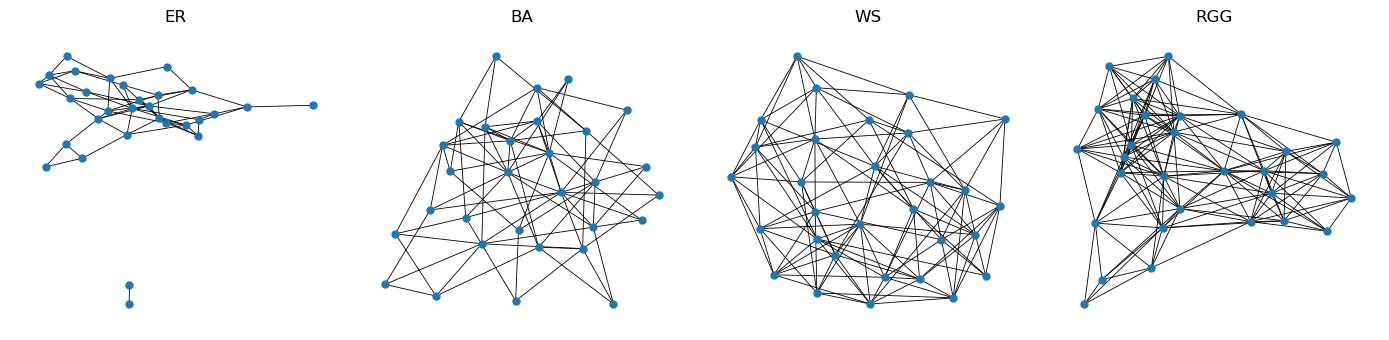

In [3]:
#Visualize random graphs: an intuitive view of the structural differences available to the classifier.

fig, axes = plt.subplots(1, 4, figsize = (14, 3.5))

for ax, model_name in zip(axes, Model_names):
    G = generate_networkx_graph(model_name, 30)
    pos = nx.spring_layout(G, seed = SEED)
    nx.draw_networkx(G, pos, ax=ax, node_size=25, with_labels=False, width=0.6)
    ax.set_title(model_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Building the Dataset

Here, we generate 150 random graphs per model (600 graphs total)


In [4]:
def graph_dataset(graphs_per_model = 150, n_min = 20, n_max = 40):
    dataset = []

    for model in Model_names:
        for _ in range(graphs_per_model):
            n = random.randint(n_min, n_max)
            G = generate_networkx_graph(model, n)
            dataset.append(nx_to_pyg(G, Labels[model]))

    random.shuffle(dataset)
    return dataset


dataset = graph_dataset()

print("Total graphs:", len(dataset))
print("First graph:", dataset[0])
print("Nodes:", dataset[0].num_nodes)
print("Edges:", dataset[0].num_edges // 2)

Total graphs: 600
First graph: Data(x=[31, 2], edge_index=[2, 200], y=[1])
Nodes: 31
Edges: 100


In [5]:
labels = np.array([int(g.y.item()) for g in dataset])
counts = np.bincount(labels, minlength = len(Model_names))

for name, count in zip(Model_names, counts):
    print(f"{name}: {count}")

ER: 150
BA: 150
WS: 150
RGG: 150


## Train / Validation / Test Split

The split is performed at the graph level. Each graph is one independent classification example.


In [6]:
indices = np.arange(len(dataset))

train_idx, temp_idx = train_test_split(
    indices,
    test_size = 0.30,
    random_state = SEED,
    stratify=labels,)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size = 0.50,
    random_state = SEED,
    stratify=labels[temp_idx],)

train_dataset = [dataset[i] for i in train_idx]
val_dataset = [dataset[i] for i in val_idx]
test_dataset = [dataset[i] for i in test_idx]

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 420
Validation: 90
Test: 90


## Defining the GCN

Here, we implement a two-layer graph convolutional network (GCN) [2,3].

Architecture: **node features → GCN → GCN → global mean pooling → MLP → graph class**

<br>

In [7]:
class GCNClassifier(nn.Module):
    def __init__(self, in_channels =2, hidden_channels = 32, num_classes = 4):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.fc1 = nn.Linear(hidden_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p = 0.20, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        #variable-size graph -> fixed-size representation
        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        return self.fc2(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCNClassifier().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-3,
    weight_decay=1e-4) #L2-regularised Adam

#Cross-entropy loss:
criterion = nn.CrossEntropyLoss()

print("Device:", device)
print(model)

Device: cpu
GCNClassifier(
  (conv1): GCNConv(2, 32)
  (conv2): GCNConv(32, 32)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
)


In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

def run_epoch(loader, training=False):
    model.train(training)

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch)

        loss = criterion(
            logits,
            batch.y.view(-1))

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        correct += (
            logits.argmax(dim=1) == batch.y.view(-1)
        ).sum().item()
        total += batch.num_graphs

    return total_loss / total, correct / total


## Training the GNN

We use only 40 epochs. The best validation model is retained.


In [9]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],}

best_val_acc = -1.0
best_state = None

for epoch in range(1, 41):
    train_loss, train_acc = run_epoch(
        train_loader,
        training=True)

    with torch.no_grad():
        val_loss, val_acc = run_epoch(
            val_loader,
            training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_loss:.3f} | "
            f"train acc={train_acc:.3f} | "
            f"val acc={val_acc:.3f}")

model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_val_acc:.3f}")

Epoch 01 | train loss=1.388 | train acc=0.250 | val acc=0.244
Epoch 05 | train loss=1.309 | train acc=0.326 | val acc=0.389
Epoch 10 | train loss=0.920 | train acc=0.550 | val acc=0.544
Epoch 15 | train loss=0.682 | train acc=0.717 | val acc=0.667
Epoch 20 | train loss=0.586 | train acc=0.748 | val acc=0.689
Epoch 25 | train loss=0.567 | train acc=0.726 | val acc=0.689
Epoch 30 | train loss=0.542 | train acc=0.748 | val acc=0.689
Epoch 35 | train loss=0.517 | train acc=0.767 | val acc=0.678
Epoch 40 | train loss=0.516 | train acc=0.752 | val acc=0.689
Best validation accuracy: 0.700


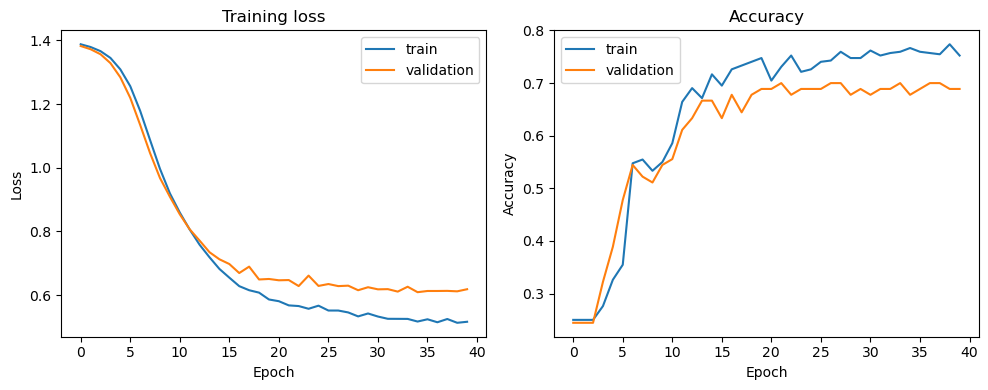

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluating on Unseen Graphs


              precision    recall  f1-score   support

          ER      0.742     1.000     0.852        23
          BA      0.684     0.591     0.634        22
          WS      0.765     0.591     0.667        22
         RGG      1.000     1.000     1.000        23

    accuracy                          0.800        90
   macro avg      0.798     0.795     0.788        90
weighted avg      0.799     0.800     0.791        90



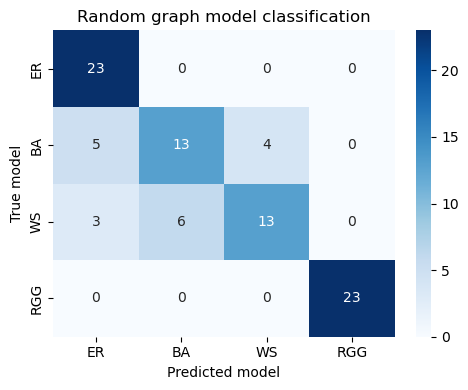

In [11]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch)

        y_true.extend(batch.y.view(-1).cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())

print(classification_report(
        y_true,
        y_pred,
        target_names = Model_names,
        digits=3))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels = Model_names,
    yticklabels = Model_names,
    cmap="Blues")

plt.xlabel("Predicted model")
plt.ylabel("True model")
plt.title("Random graph model classification")
plt.tight_layout()
plt.show()

## References

[1] PyTorch Geometric (PyG) - https://pytorch-geometric.readthedocs.io/en/latest<br>
[2] GCNConv - https://pytorch-geometric.readthedocs.io/en/2.4.0/generated/torch_geometric.nn.conv.GCNConv.html<br>
[3] Kipf, T. N. and Welling, M. (2017). Semi-Supervised Classification with Graph Convolutional Networks. arXiv:1609.02907
